In [25]:
import pandas as pd
from utils import preprocess_text_column
from utils import apply_vader
from utils import train_and_evaluate
from utils import plot_sentiment_timeseries

In [26]:
# Load the extracted CSV file
df = pd.read_csv("tweets/all_tweets.csv")

In [27]:
# Apply preprocessing
df = preprocess_text_column(df)

In [28]:
# Display processed output
print(df[['cleaned_text', 'tokens']])

# Optionally save to new CSV
df.to_csv("all_tweets_processed.csv", index=False)

                                           cleaned_text  \
0                                      Incredibile Hulk   
1                                          Suspicious….   
2     A strike on the young nation will unite the co...   
3     #ETHWUSDT \r\n\r\nEntry: 1.43\r\n\r\nTarget 1:...   
4     #Atomicals Virtual Machine (AVM) es un sistema...   
...                                                 ...   
1890  Borsa İstanbul, PRDGS Hisseleri İçin Kredili İ...   
1891  Best Casino Online ➜ http://lit.link/CASINO【แจ...   
1892            Mined Bitcoin on an old laptop in 2013.   
1893                                      This is great   
1894   But he bought paper bitcoin so it doesn't matter   

                                                 tokens  
0                                   [incredibile, hulk]  
1                                          [suspicious]  
2     [strike, young, nation, unite, continent, gene...  
3     [entry, 143, target, 1, 157target, 2, 165targe...  
4

In [29]:
# Load the preprocessed tweet data
df = pd.read_csv("all_tweets_processed.csv")

In [30]:
# Apply VADER sentiment analysis and save result to 'sentiment_labeled.csv'
df = apply_vader(df)

✅ Saved labeled data to sentiment_labeled.csv


In [31]:
# Train and evaluate classifier using sentiment labels
train_and_evaluate(df)

✅ Model Evaluation
Accuracy: 0.6939313984168866
Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.10      0.18        68
     neutral       0.70      0.87      0.78       177
    positive       0.67      0.76      0.71       134

    accuracy                           0.69       379
   macro avg       0.75      0.58      0.56       379
weighted avg       0.72      0.69      0.65       379



c:\Users\Vishwa\OneDrive\Desktop\UMD SYLLABUS\SEM 2\DATA 605\src\tutorials\DATA605\Spring2025\projects\TutorTask98_Spring2025_Real-Time_Bitcoin_Sentiment_Analysis_Using_NLTK_and_Selenium\utils.py:979: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sentiment_time = df['compound'].resample('H').mean()


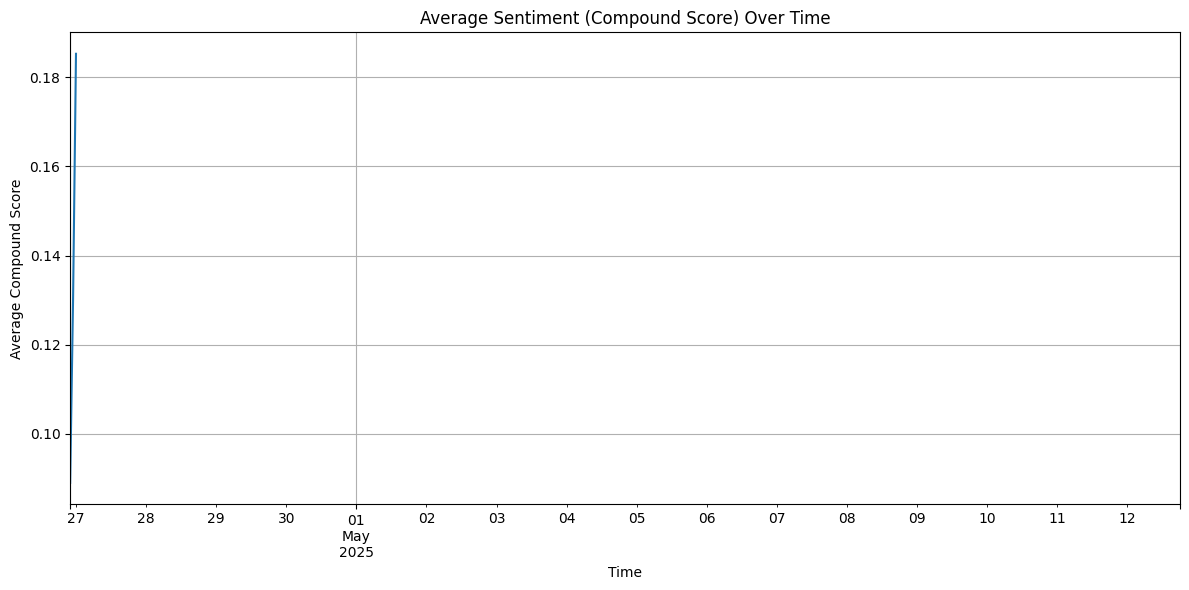

c:\Users\Vishwa\OneDrive\Desktop\UMD SYLLABUS\SEM 2\DATA 605\src\tutorials\DATA605\Spring2025\projects\TutorTask98_Spring2025_Real-Time_Bitcoin_Sentiment_Analysis_Using_NLTK_and_Selenium\utils.py:992: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sentiment_counts = df.resample('H')['sentiment_label'].value_counts().unstack().fillna(0)


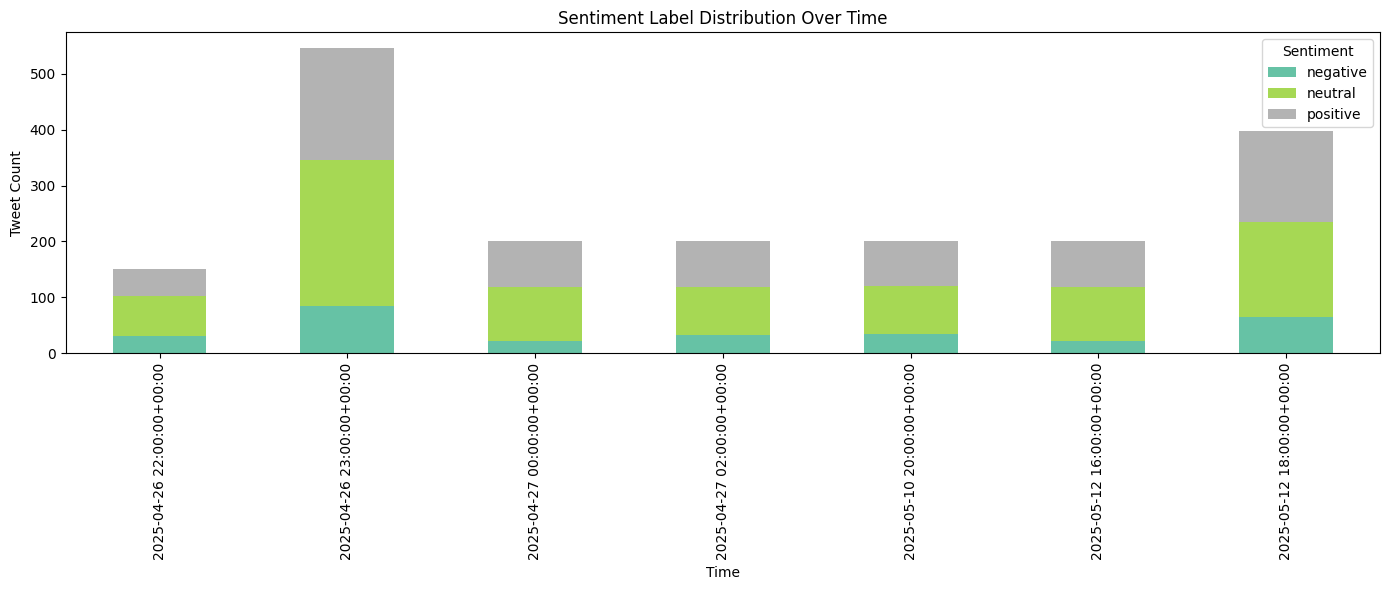

In [32]:
plot_sentiment_timeseries('sentiment_labeled.csv')

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def analyze_sentiment_btc_correlation(sentiment_file='sentiment_labeled.csv', btc_file='btc_prices.csv'):
    # Load sentiment data
    df_sent = pd.read_csv(sentiment_file)
    df_sent['Timestamp'] = pd.to_datetime(df_sent['Timestamp'], errors='coerce')
    df_sent = df_sent.dropna(subset=['Timestamp'])
    df_sent.set_index('Timestamp', inplace=True)

    # Average compound score per hour
    sentiment_hourly = df_sent['compound'].resample('H').mean().rename("Sentiment")

    # Load BTC price data
    df_btc = pd.read_csv(btc_file)
    df_btc['Timestamp'] = pd.to_datetime(df_btc['Timestamp'], errors='coerce')
    df_btc = df_btc.dropna(subset=['Timestamp'])
    df_btc.set_index('Timestamp', inplace=True)

    # Resample price data hourly to match sentiment resolution
    btc_hourly = df_btc['Price'].resample('H').mean().rename("BTC Price")

    # Merge datasets on time
    merged = pd.concat([sentiment_hourly, btc_hourly], axis=1).dropna()

    # Plot both
    plt.figure(figsize=(12, 6))
    ax1 = merged['Sentiment'].plot(label='Avg Sentiment', color='tab:blue')
    ax2 = merged['BTC Price'].plot(secondary_y=True, label='BTC Price', color='tab:red')
    ax1.set_ylabel("Sentiment")
    ax2.set_ylabel("BTC Price")
    plt.title("Sentiment vs. Bitcoin Price Over Time")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Correlation
    corr, _ = pearsonr(merged['Sentiment'], merged['BTC Price'])
    print(f"📈 Pearson Correlation between Sentiment and BTC Price: {corr:.4f}")


In [34]:
analyze_sentiment_btc_correlation('sentiment_labeled.csv', 'btc_prices.csv')


C:\Users\Vishwa\AppData\Local\Temp\ipykernel_22944\580645708.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sentiment_hourly = df_sent['compound'].resample('H').mean().rename("Sentiment")


FileNotFoundError: [Errno 2] No such file or directory: 'btc_prices.csv'